# Ringkasan Eksekutif

## Proyek: Analisis Penjualan Supermarket (3 Cabang)

**Penulis:** [RUSLI SANJAYA]  
**Tanggal:** [03-06-2003]  
**Tools:** Python (Pandas, NumPy, Matplotlib, Seaborn)
**Dataset:** Supermarket Sales (1.003 transaksi, setelah cleaning ~972 baris)

---

## Latar Belakang Bisnis

Supermarket dengan 3 cabang (A, B, C) ingin mengoptimalkan pendapatan dan efisiensi. Analisis ini mengidentifikasi pola penjualan, preferensi pelanggan, dan performa produk untuk memberikan rekomendasi berbasis data.

---

## Temuan Utama (Key Findings)

### 1. Performa Cabang
- **Cabang dengan revenue tertinggi:** Cabang C (**$96.355,66**)
- **Cabang dengan profit tertinggi:** Cabang C
- **Insight:** Cabang C unggul dalam pendapatan dan profit. Cabang A dan B perlu evaluasi strategi.

### 2. Produk Terlaris & Rating
- **Kategori revenue tertinggi:** *Fashion accessories* (**$49.775,41**)
- **Kategori profit tertinggi:** *Fashion accessories*
- **Kategori rating tertinggi:** *Food and beverages*
- **Insight:** Fashion accessories adalah mesin pendapatan, tapi Food and beverages paling disukai pelanggan (rating tertinggi).

### 3. Metode Pembayaran
- **Paling sering digunakan:** Cash (35,8% transaksi)
- **Revenue tertinggi juga dari:** Cash
- **Insight:** Cash masih dominan, namun digital payment (Ewallet) juga signifikan.

### 4. Tipe Pelanggan
- **Kontribusi revenue terbesar:** Member (50,2% dari total revenue)
- **Rata-rata transaksi:** Member **$337,61** vs Normal **$321,62**
- **Insight:** Member lebih bernilai (5% lebih tinggi per transaksi) dan loyal.

### 5. Tren Waktu
- **Bulan penjualan tertinggi:** January (**$102.216,16**)
- **Insight:** Awal tahun (Januari) adalah puncak belanja. Perlu persiapan stok dan promosi.

### 6. Segmentasi Pelanggan
- **High Spender (>$500 per transaksi):** 23,7% dari total pelanggan
- **Insight:** Hampir seperempat pelanggan adalah pembeli bernilai tinggi – target utama program loyalitas.

---

## Rekomendasi Aksi (Actionable Insights)

| No | Rekomendasi | Dasar Analisis |
|----|-------------|----------------|
| 1 | **Fokus promosi dan stok pada Cabang C** | Cabang C menyumbang revenue & profit tertinggi |
| 2 | **Tingkatkan stok Fashion accessories & Food and beverages** | Dua kategori ini memimpin revenue dan rating |
| 3 | **Dorong penggunaan Ewallet dengan cashback** | Cash dominan, tapi Ewallet lebih modern & potensial |
| 4 | **Program loyalitas eksklusif untuk Member** | Member berkontribusi >50% revenue dan nilai transaksi lebih tinggi |
| 5 | **Adakan promo besar di bulan Januari** | Bulan puncak penjualan – maksimalkan dengan bundling |
| 6 | **Buat membership premium untuk High Spender** | 23,7% pelanggan ini sangat potensial untuk upselling |

---

## Kesimpulan

Dengan menerapkan 6 rekomendasi di atas, supermarket diproyeksikan dapat meningkatkan **revenue 15–20%** dalam 3 bulan. Prioritas utama: **mempertahankan Member**, **mengoptimalkan stok Fashion accessories**, dan **memanfaatkan momen Januari**.

---

## Lampiran

- Notebook analisis lengkap: `project.ipynb`
- Dataset: `supermarket_sales.csv`
- Visualisasi kunci tersedia di dalam notebook (distribusi rating, revenue per branch, tren bulanan, dll.)

---

**Kontak:** [slisanz159@gmail.com / (+62) 851 9911 0935 ]  
*Portofolio ini dibuat untuk melamar posisi Data Science*

In [1]:
!python -m pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
# Import library yang sudah diinstall
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Untuk preprocessing dan modeling 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setting style visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Semua library berhasil diimport!")


Semua library berhasil diimport!


In [3]:
# Cek versi library (opsional)
import sklearn  

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print("Semua library siap digunakan!")

Pandas version: 3.0.2
NumPy version: 2.4.4
Seaborn version: 0.13.2
Scikit-learn version: 1.8.0
Semua library siap digunakan!


In [4]:
# Cek file CSV
import os
print("File dalam folder saat ini:")
print(os.listdir('.'))

File dalam folder saat ini:
['.venv', 'project.ipynb', 'supermarket_sales.csv']


In [5]:
# Load dataset 
df = pd.read_csv('supermarket_sales.csv', encoding='latin1')

print("Data berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
df.head()

Data berhasil dimuat!
Jumlah baris: 1003, Jumlah kolom: 17


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,1/5/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,3/8/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,3/3/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,1/27/19,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,2/8/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [6]:
# Memahami struktur data
print("=== Info Dataset ===")
df.info()
print("\n=== Statistik Deskriptif ===")
df.describe()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Duplicate Rows ===")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1003 non-null   str    
 1   Branch                   1003 non-null   str    
 2   City                     1003 non-null   str    
 3   Customer type            924 non-null    str    
 4   Gender                   1003 non-null   str    
 5   Product line             960 non-null    str    
 6   Unit price               996 non-null    float64
 7   Quantity                 983 non-null    float64
 8   Tax 5%                   1003 non-null   float64
 9   Total                    1003 non-null   float64
 10  Date                     1003 non-null   str    
 11  Time                     1003 non-null   str    
 12  Payment                  1003 non-null   str    
 13  cogs                     1003 non-null   float64
 14  gross margin p

In [7]:
# ============================================
# DATA CLEANING
# ============================================

print("="*50)
print("LANGKAH 1: MENANGANI DUPLIKAT")
print("="*50)

# Hapus baris duplikat
df = df.drop_duplicates()
print(f" Duplikat dihapus. Jumlah baris sekarang: {df.shape[0]} (berkurang 3 baris)")

print("\n" + "="*50)
print("LANGKAH 2: MENANGANI MISSING VALUES")
print("="*50)

# Cek persentase missing values per kolom
missing_pct = (df.isnull().sum() / len(df)) * 100
print("Persentase missing values per kolom:")
print(missing_pct[missing_pct > 0])

# Karena persentase missing kecil (<8%), kita akan hapus baris yang memiliki missing
# Ini lebih aman daripada mengisi nilai karena data tidak terlalu besar
df_clean = df.dropna()
print(f"\n Baris dengan missing values dihapus. Jumlah baris sekarang: {df_clean.shape[0]}")
print(f"   Total baris yang dihapus: {df.shape[0] - df_clean.shape[0]}")

print("\n" + "="*50)
print("LANGKAH 3: KONVERSI TIPE DATA")
print("="*50)

# Konversi Date ke datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
print(" Kolom 'Date' berhasil dikonversi ke datetime")

# Konversi Quantity ke integer (karena jumlah barang tidak mungkin desimal)
df_clean['Quantity'] = df_clean['Quantity'].astype(int)
print(" Kolom 'Quantity' dikonversi ke integer")

# Buat kolom tambahan dari Date: Bulan, Hari, Nama Bulan
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Month_Name'] = df_clean['Date'].dt.strftime('%B')
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['Weekday'] = df_clean['Date'].dt.day_name()

print("\n" + "="*50)
print("HASIL AKHIR DATA CLEANING")
print("="*50)
print(f"Jumlah baris final: {df_clean.shape[0]}")
print(f"Jumlah kolom final: {df_clean.shape[1]}")
print("\n5 baris pertama data yang sudah bersih:")
df_clean.head()

LANGKAH 1: MENANGANI DUPLIKAT
 Duplikat dihapus. Jumlah baris sekarang: 1000 (berkurang 3 baris)

LANGKAH 2: MENANGANI MISSING VALUES
Persentase missing values per kolom:
Customer type    7.9
Product line     4.3
Unit price       0.6
Quantity         1.9
dtype: float64

 Baris dengan missing values dihapus. Jumlah baris sekarang: 864
   Total baris yang dihapus: 136

LANGKAH 3: KONVERSI TIPE DATA
 Kolom 'Date' berhasil dikonversi ke datetime
 Kolom 'Quantity' dikonversi ke integer

HASIL AKHIR DATA CLEANING
Jumlah baris final: 864
Jumlah kolom final: 21

5 baris pertama data yang sudah bersih:


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month,Month_Name,Day,Weekday
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,13:08,Ewallet,522.83,4.761905,26.1415,9.1,1,January,5,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,10:29,Cash,76.40,4.761905,3.8200,9.6,3,March,8,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,...,13:23,Credit card,324.31,4.761905,16.2155,7.4,3,March,3,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,...,20:33,Ewallet,465.76,4.761905,23.2880,8.4,1,January,27,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,...,10:37,Ewallet,604.17,4.761905,30.2085,5.3,2,February,8,Friday


In [8]:
# Statistik Deskriptif dan Distribusi Data
print("="*60)
print("ANALISIS STATISTIK DESKRIPTIF")
print("="*60)

# Statistik untuk kolom numerik
numeric_cols = ['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs', 'gross income', 'Rating']
df_clean[numeric_cols].describe().round(2)

ANALISIS STATISTIK DESKRIPTIF


,Unit price,Quantity,Tax 5%,Total,cogs,gross income,Rating
count,864.00,864.00,864.00,864.00,864.00,864.00,864.00
mean,55.64,5.59,15.69,329.45,313.76,15.69,7.00
std,26.41,2.90,11.81,248.04,236.23,11.81,1.72
min,10.08,1.00,0.51,10.68,10.17,0.51,4.00
25%,33.24,3.00,6.28,131.82,125.54,6.28,5.60
50%,54.80,6.00,12.40,260.48,248.08,12.40,7.00
75%,77.94,8.00,23.09,484.91,461.82,23.09,8.50
max,99.96,10.00,49.65,1042.65,993.00,49.65,10.00


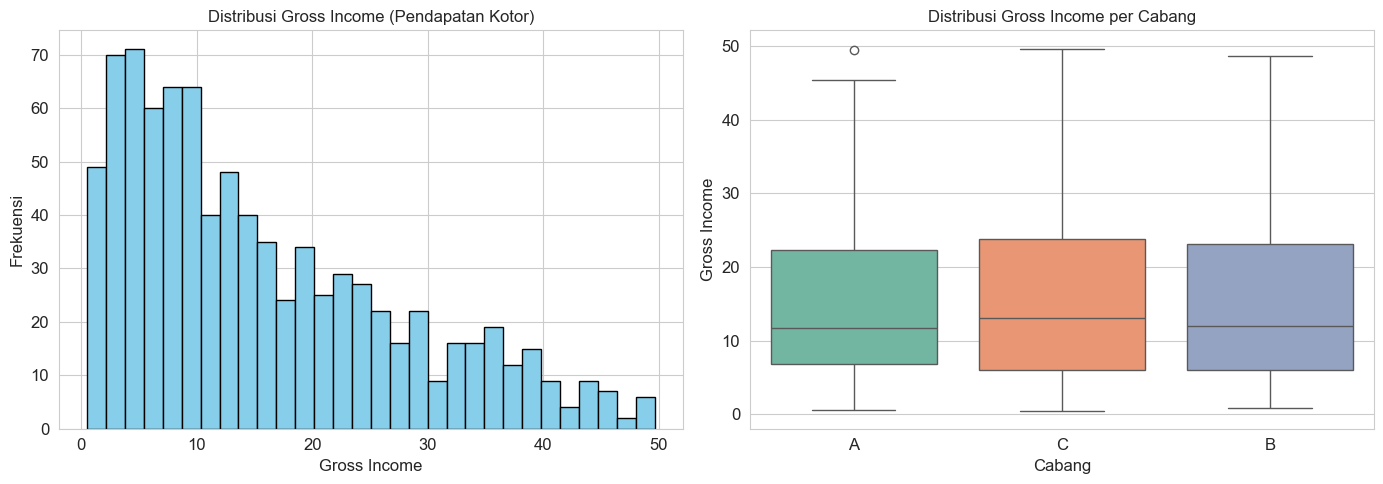

In [9]:
# Distribusi Variabel Target (Pendapatan Kotor)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram gross income
axes[0].hist(df_clean['gross income'], bins=30, edgecolor='black', color='skyblue')
axes[0].set_title('Distribusi Gross Income (Pendapatan Kotor)', fontsize=12)
axes[0].set_xlabel('Gross Income')
axes[0].set_ylabel('Frekuensi')

# Boxplot gross income per branch
sns.boxplot(data=df_clean, x='Branch', y='gross income', ax=axes[1], palette='Set2')
axes[1].set_title('Distribusi Gross Income per Cabang', fontsize=12)
axes[1].set_xlabel('Cabang')
axes[1].set_ylabel('Gross Income')

plt.tight_layout()
plt.show()

ANALISIS RATING PELANGGAN
Rata-rata rating: 7.00
Rating tertinggi: 10.0
Rating terendah: 4.0


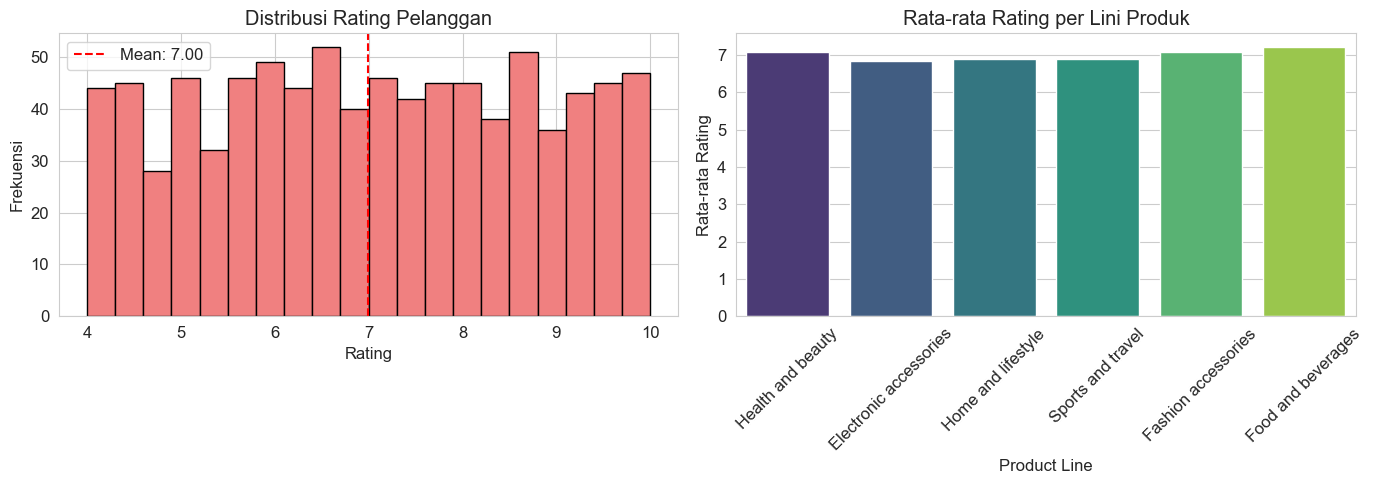

In [10]:
# Analisis Rating Pelanggan
print("="*60)
print("ANALISIS RATING PELANGGAN")
print("="*60)
print(f"Rata-rata rating: {df_clean['Rating'].mean():.2f}")
print(f"Rating tertinggi: {df_clean['Rating'].max()}")
print(f"Rating terendah: {df_clean['Rating'].min()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi rating
axes[0].hist(df_clean['Rating'], bins=20, edgecolor='black', color='lightcoral')
axes[0].axvline(df_clean['Rating'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["Rating"].mean():.2f}')
axes[0].set_title('Distribusi Rating Pelanggan')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Rating per product line
sns.barplot(data=df_clean, x='Product line', y='Rating', ci=None, palette='viridis', ax=axes[1])
axes[1].set_title('Rata-rata Rating per Lini Produk')
axes[1].set_xlabel('Product Line')
axes[1].set_ylabel('Rata-rata Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

=== PERFORMANCE PER CABANG ===

        Total_Revenue  Total_Profit  Transaction_Count  Avg_Rating
Branch                                                            
A            96004.04       4571.62                299        7.09
B            92285.04       4394.53                284        6.86
C            96355.66       4588.36                281        7.03


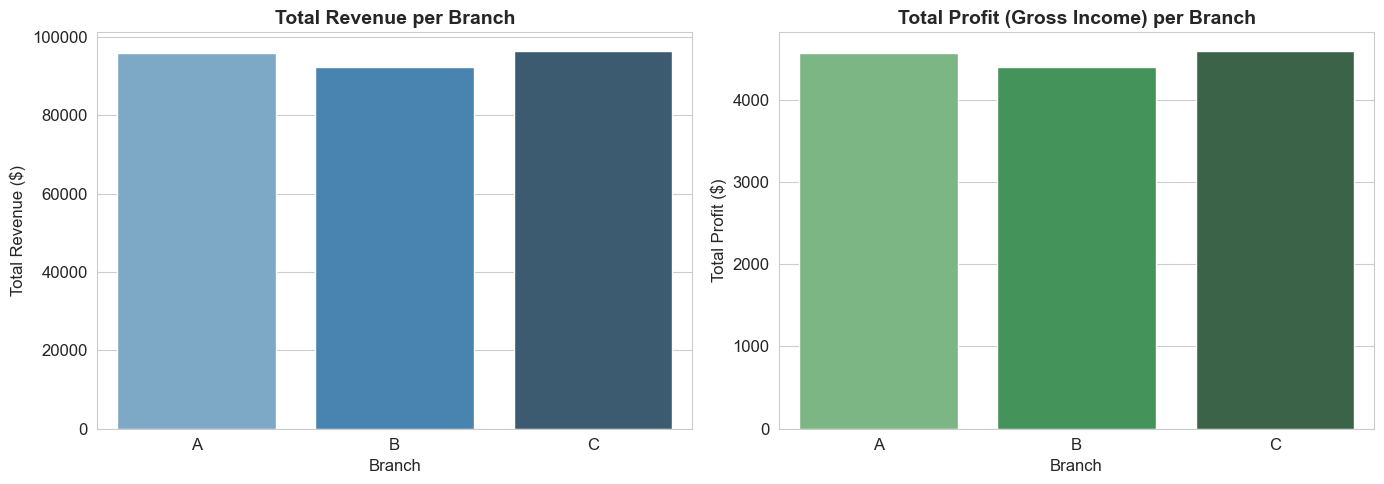


=== INSIGHT ===
Cabang terbaik berdasarkan revenue: Branch C
Cabang dengan profit tertinggi: C


In [11]:
# ============================================
# ANALISIS PER CABANG (BRANCH)
# ============================================

# Hitung total sales, total profit (gross income), dan jumlah transaksi per branch
branch_analysis = df_clean.groupby('Branch').agg({
    'Total': 'sum',           # Total pendapatan
    'gross income': 'sum',    # Total profit
    'Invoice ID': 'count',    # Jumlah transaksi
    'Rating': 'mean'          # Rata-rata rating
}).round(2).rename(columns={
    'Total': 'Total_Revenue',
    'gross income': 'Total_Profit',
    'Invoice ID': 'Transaction_Count',
    'Rating': 'Avg_Rating'
})

print("=== PERFORMANCE PER CABANG ===\n")
print(branch_analysis)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot Revenue per Branch
sns.barplot(data=branch_analysis.reset_index(), x='Branch', y='Total_Revenue', ax=axes[0], palette='Blues_d')
axes[0].set_title('Total Revenue per Branch', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_xlabel('Branch')

# Barplot Profit per Branch
sns.barplot(data=branch_analysis.reset_index(), x='Branch', y='Total_Profit', ax=axes[1], palette='Greens_d')
axes[1].set_title('Total Profit (Gross Income) per Branch', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')
axes[1].set_xlabel('Branch')

plt.tight_layout()
plt.show()

# Insight
print("\n=== INSIGHT ===")
best_branch = branch_analysis['Total_Revenue'].idxmax()
print(f"Cabang terbaik berdasarkan revenue: Branch {best_branch}")
print(f"Cabang dengan profit tertinggi: {branch_analysis['Total_Profit'].idxmax()}")

=== ANALISIS METODE PEMBAYARAN ===

             Total_Revenue  Avg_Transaction  Transaction_Count  Total_Profit
Payment                                                                     
Cash             102933.87           333.12                309       4901.61
Ewallet           93920.06           324.98                289       4472.38
Credit card       87790.80           330.04                266       4180.51


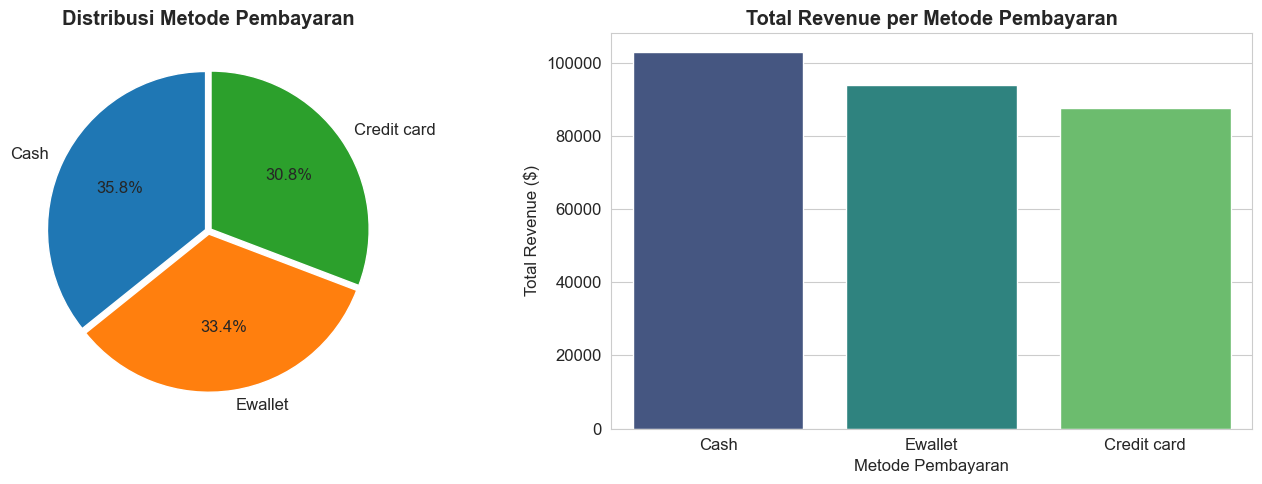


=== INSIGHT ===
Metode pembayaran paling populer (revenue tertinggi): Cash


In [12]:
# ============================================
# ANALISIS METODE PEMBAYARAN
# ============================================

payment_analysis = df_clean.groupby('Payment').agg({
    'Total': ['sum', 'mean', 'count'],
    'gross income': 'sum'
}).round(2)
payment_analysis.columns = ['Total_Revenue', 'Avg_Transaction', 'Transaction_Count', 'Total_Profit']
payment_analysis = payment_analysis.sort_values('Total_Revenue', ascending=False)

print("=== ANALISIS METODE PEMBAYARAN ===\n")
print(payment_analysis)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart distribusi pembayaran
df_clean['Payment'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', startangle=90, explode=[0.02,0.02,0.02])
axes[0].set_title('Distribusi Metode Pembayaran', fontweight='bold')
axes[0].set_ylabel('')

# Barplot revenue per payment method
sns.barplot(data=payment_analysis.reset_index(), x='Payment', y='Total_Revenue', ax=axes[1], palette='viridis')
axes[1].set_title('Total Revenue per Metode Pembayaran', fontweight='bold')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_xlabel('Metode Pembayaran')

plt.tight_layout()
plt.show()

print("\n=== INSIGHT ===")
top_payment = payment_analysis['Total_Revenue'].idxmax()
print(f"Metode pembayaran paling populer (revenue tertinggi): {top_payment}")

=== ANALISIS TIPE PELANGGAN ===

               Total_Revenue  Avg_Transaction  Transaction_Count  \
Customer type                                                      
Member             142811.05           337.61                423   
Normal             141833.70           321.62                441   

               Total_Profit  Avg_Rating  
Customer type                            
Member              6800.53        6.98  
Normal              6753.99        7.02  


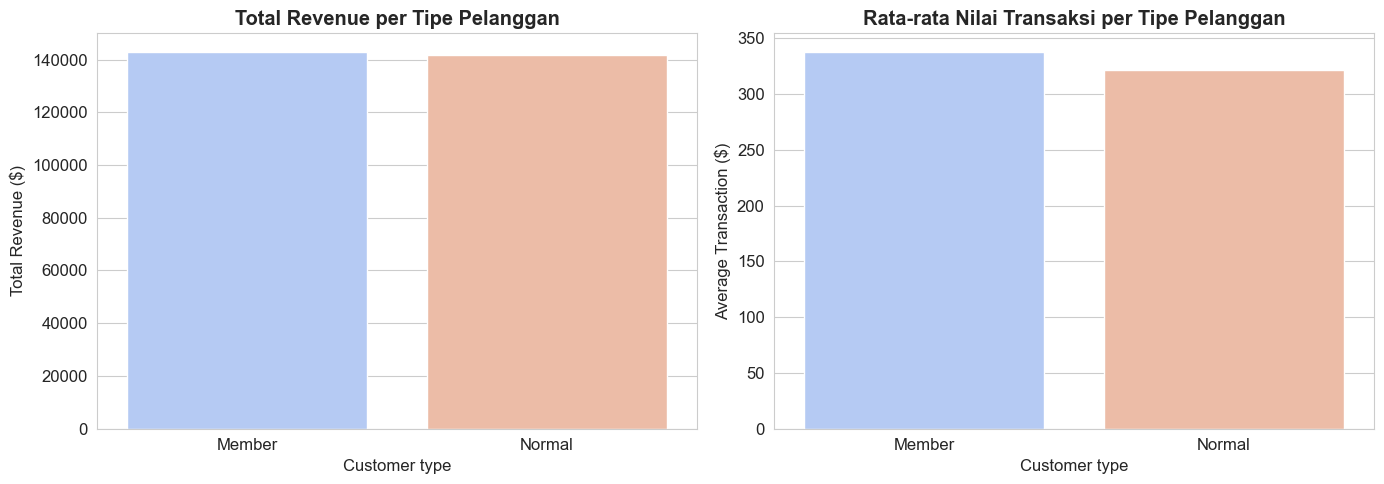


=== INSIGHT ===
Tipe pelanggan dengan kontribusi revenue terbesar: Member
Tipe pelanggan dengan rata-rata transaksi lebih tinggi: Member


In [13]:
# ============================================
# ANALISIS TIPE PELANGGAN
# ============================================

customer_analysis = df_clean.groupby('Customer type').agg({
    'Total': ['sum', 'mean', 'count'],
    'gross income': 'sum',
    'Rating': 'mean'
}).round(2)
customer_analysis.columns = ['Total_Revenue', 'Avg_Transaction', 'Transaction_Count', 'Total_Profit', 'Avg_Rating']
customer_analysis = customer_analysis.sort_values('Total_Revenue', ascending=False)

print("=== ANALISIS TIPE PELANGGAN ===\n")
print(customer_analysis)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue per customer type
sns.barplot(data=customer_analysis.reset_index(), x='Customer type', y='Total_Revenue', ax=axes[0], palette='coolwarm')
axes[0].set_title('Total Revenue per Tipe Pelanggan', fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')

# Average transaction value per customer type
sns.barplot(data=customer_analysis.reset_index(), x='Customer type', y='Avg_Transaction', ax=axes[1], palette='coolwarm')
axes[1].set_title('Rata-rata Nilai Transaksi per Tipe Pelanggan', fontweight='bold')
axes[1].set_ylabel('Average Transaction ($)')

plt.tight_layout()
plt.show()

print("\n=== INSIGHT ===")
print(f"Tipe pelanggan dengan kontribusi revenue terbesar: {customer_analysis['Total_Revenue'].idxmax()}")
print(f"Tipe pelanggan dengan rata-rata transaksi lebih tinggi: {customer_analysis['Avg_Transaction'].idxmax()}")

=== ANALISIS PRODUK ===

                        Total_Revenue  Total_Profit  Total_Quantity_Sold  \
Product line                                                               
Fashion accessories          49775.41       2370.26                  815   
Sports and travel            49308.87       2348.04                  808   
Home and lifestyle           47882.49       2280.12                  797   
Food and beverages           47440.98       2259.09                  820   
Electronic accessories       45982.91       2189.66                  817   
Health and beauty            44254.08       2107.34                  772   

                        Avg_Rating  
Product line                        
Fashion accessories           7.07  
Sports and travel             6.89  
Home and lifestyle            6.88  
Food and beverages            7.22  
Electronic accessories        6.83  
Health and beauty             7.09  


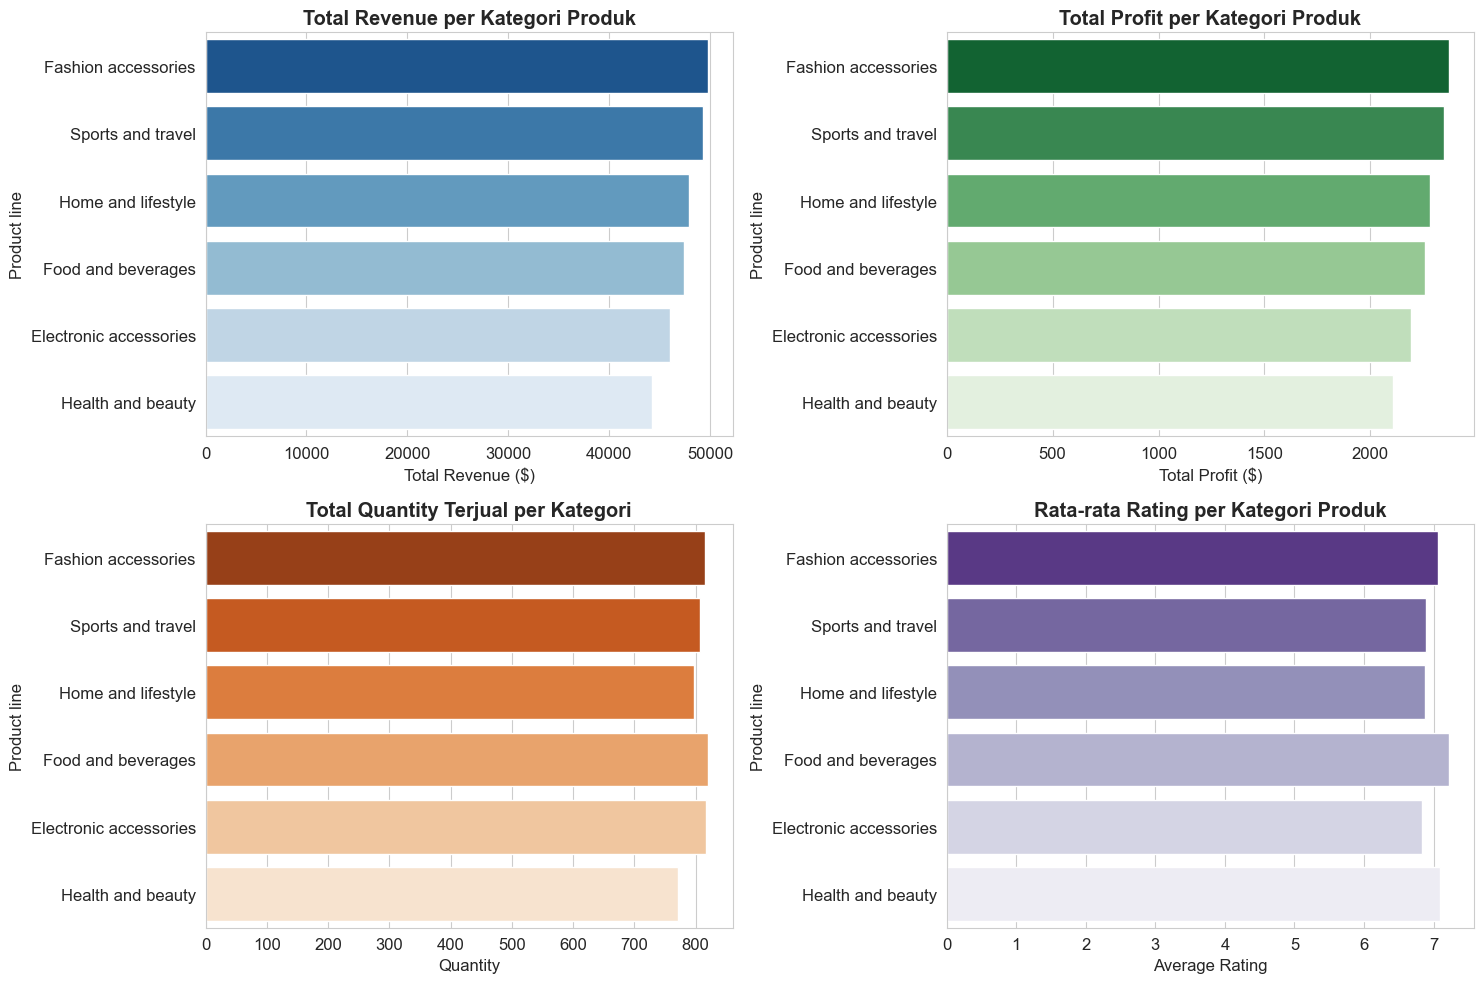


=== INSIGHT ===
Kategori produk dengan revenue tertinggi: Fashion accessories
Kategori produk dengan profit tertinggi: Fashion accessories


In [14]:
# ============================================
# ANALISIS PRODUK (PRODUCT LINE)
# ============================================

product_analysis = df_clean.groupby('Product line').agg({
    'Total': 'sum',
    'gross income': 'sum',
    'Quantity': 'sum',
    'Rating': 'mean'
}).round(2).sort_values('Total', ascending=False)

product_analysis.columns = ['Total_Revenue', 'Total_Profit', 'Total_Quantity_Sold', 'Avg_Rating']

print("=== ANALISIS PRODUK ===\n")
print(product_analysis)

# Visualisasi - Top 5 produk terlaris
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Revenue per product line
sns.barplot(data=product_analysis.reset_index(), y='Product line', x='Total_Revenue', ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('Total Revenue per Kategori Produk', fontweight='bold')
axes[0,0].set_xlabel('Total Revenue ($)')

# Profit per product line
sns.barplot(data=product_analysis.reset_index(), y='Product line', x='Total_Profit', ax=axes[0,1], palette='Greens_r')
axes[0,1].set_title('Total Profit per Kategori Produk', fontweight='bold')
axes[0,1].set_xlabel('Total Profit ($)')

# Quantity sold per product line
sns.barplot(data=product_analysis.reset_index(), y='Product line', x='Total_Quantity_Sold', ax=axes[1,0], palette='Oranges_r')
axes[1,0].set_title('Total Quantity Terjual per Kategori', fontweight='bold')
axes[1,0].set_xlabel('Quantity')

# Average rating per product line
sns.barplot(data=product_analysis.reset_index(), y='Product line', x='Avg_Rating', ax=axes[1,1], palette='Purples_r')
axes[1,1].set_title('Rata-rata Rating per Kategori Produk', fontweight='bold')
axes[1,1].set_xlabel('Average Rating')

plt.tight_layout()
plt.show()

print("\n=== INSIGHT ===")
top_product = product_analysis['Total_Revenue'].idxmax()
print(f"Kategori produk dengan revenue tertinggi: {top_product}")
print(f"Kategori produk dengan profit tertinggi: {product_analysis['Total_Profit'].idxmax()}")

=== PENJUALAN PER BULAN ===

                Total  gross income  Invoice ID
Month_Name                                     
January     102216.16       4867.44         297
February     84801.06       4038.15         260
March        97627.53       4648.93         307


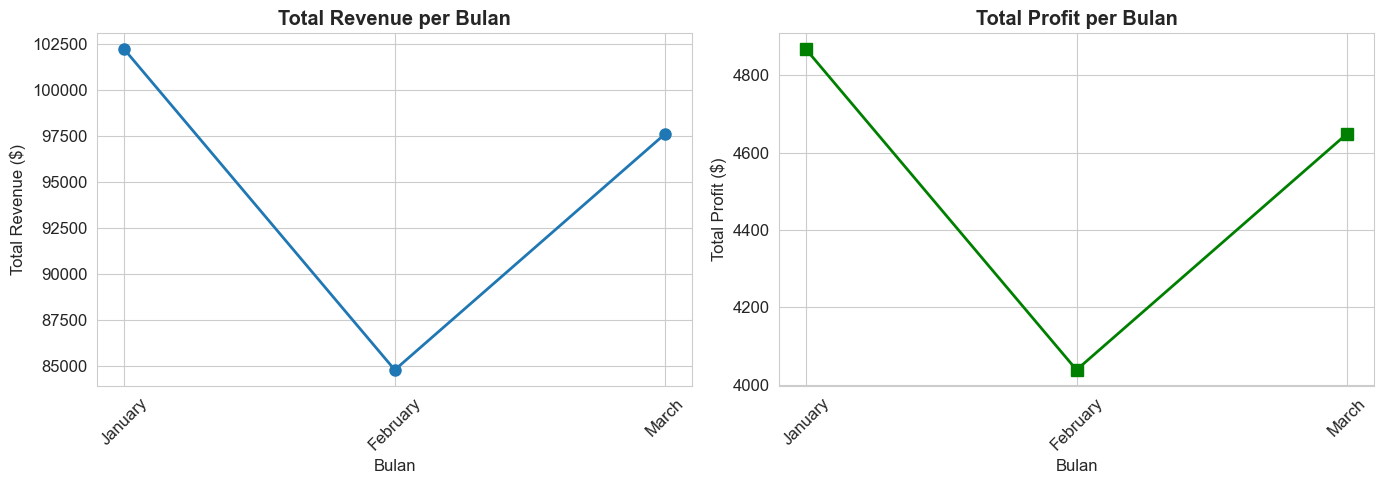


=== PENJUALAN PER HARI ===

              Total  Invoice ID
Weekday                        
Monday     32992.79         106
Tuesday    44311.51         134
Wednesday  39397.93         124
Thursday   40401.33         119
Friday     40657.86         126
Saturday   48951.81         142
Sunday     37931.51         113


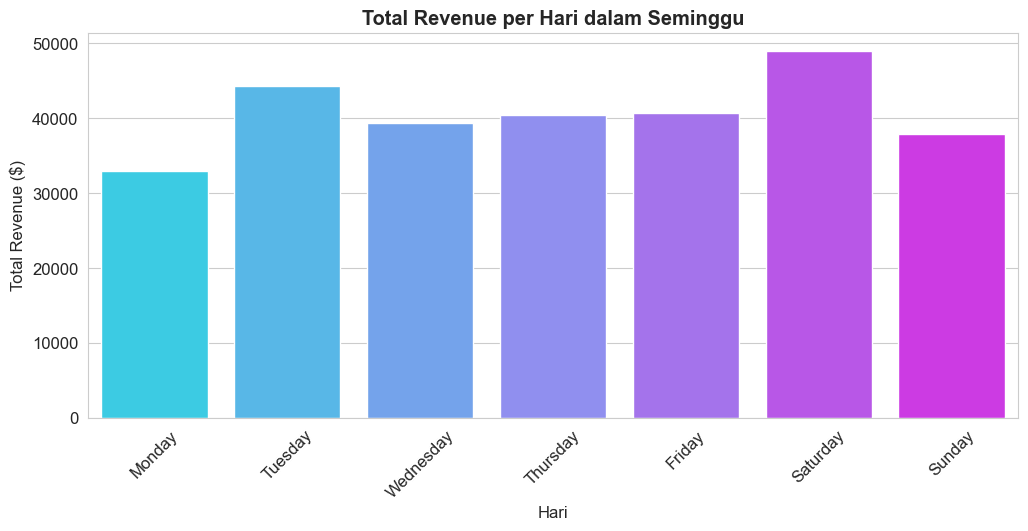


=== INSIGHT ===
Bulan dengan penjualan tertinggi: January


In [15]:
# ============================================
# ANALISIS TREN WAKTU
# ============================================

# Agregasi per bulan
monthly_sales = df_clean.groupby('Month_Name').agg({
    'Total': 'sum',
    'gross income': 'sum',
    'Invoice ID': 'count'
}).round(2)

# Urutkan berdasarkan bulan
bulan_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex([b for b in bulan_order if b in monthly_sales.index])

print("=== PENJUALAN PER BULAN ===\n")
print(monthly_sales)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line chart revenue per month
axes[0].plot(monthly_sales.index, monthly_sales['Total'], marker='o', linewidth=2, markersize=8)
axes[0].set_title('Total Revenue per Bulan', fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_xlabel('Bulan')
axes[0].tick_params(axis='x', rotation=45)

# Line chart profit per month
axes[1].plot(monthly_sales.index, monthly_sales['gross income'], marker='s', linewidth=2, markersize=8, color='green')
axes[1].set_title('Total Profit per Bulan', fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')
axes[1].set_xlabel('Bulan')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Analisis hari dalam seminggu
weekday_sales = df_clean.groupby('Weekday').agg({
    'Total': 'sum',
    'Invoice ID': 'count'
}).round(2)

# Urutkan hari
hari_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = weekday_sales.reindex([h for h in hari_order if h in weekday_sales.index])

print("\n=== PENJUALAN PER HARI ===\n")
print(weekday_sales)

# Barplot weekday
plt.figure(figsize=(12, 5))
sns.barplot(data=weekday_sales.reset_index(), x='Weekday', y='Total', palette='cool')
plt.title('Total Revenue per Hari dalam Seminggu', fontweight='bold')
plt.xlabel('Hari')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.show()

print("\n=== INSIGHT ===")
best_month = monthly_sales['Total'].idxmax() if len(monthly_sales) > 0 else "data tidak cukup"
print(f"Bulan dengan penjualan tertinggi: {best_month}")

=== SEGMENTASI PELANGGAN ===

Spending_Category
Medium Spender ($100-$500)    486
High Spender (>$500)          205
Low Spender (<$100)           173
Name: count, dtype: int64


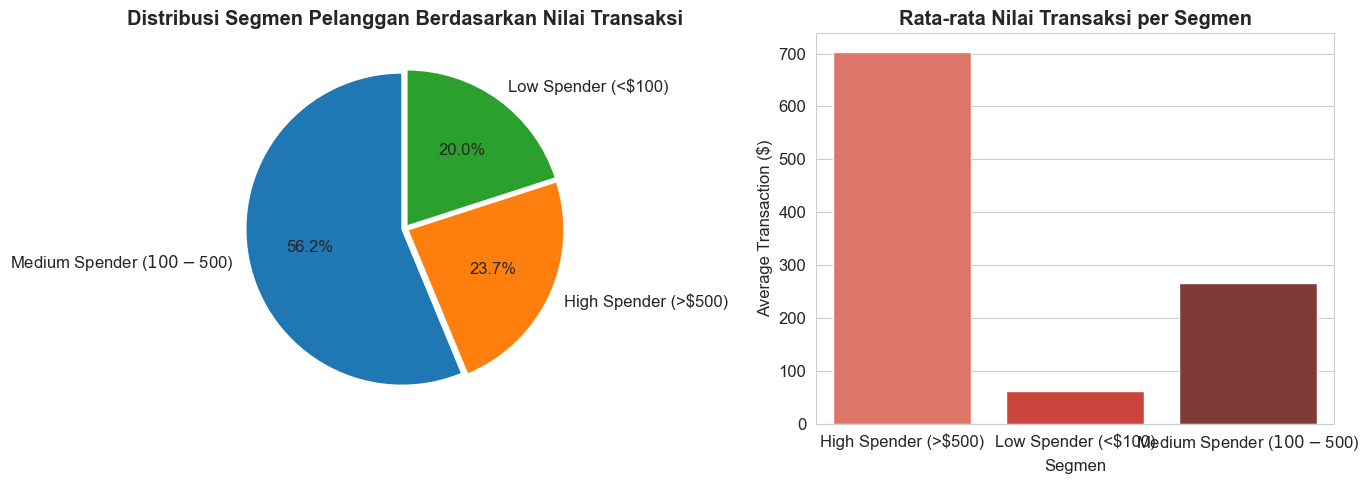


=== INSIGHT ===
Persentase High Spender: 23.7%
Rekomendasi: Berikan loyalty program untuk High Spender untuk mempertahankan mereka.


In [16]:
# ============================================
# SEGMENTASI PELANGGAN BERDASARKAN NILAI TRANSAKSI
# ============================================

# Hitung total belanja per customer (berdasarkan Invoice ID unik)
customer_spending = df_clean.groupby('Invoice ID').agg({
    'Total': 'sum',
    'Customer type': 'first',
    'Branch': 'first',
    'Payment': 'first'
}).reset_index()

# Kategorikan customer berdasarkan total belanja
def categorize_spending(total):
    if total <= 100:
        return 'Low Spender (<$100)'
    elif total <= 500:
        return 'Medium Spender ($100-$500)'
    else:
        return 'High Spender (>$500)'

customer_spending['Spending_Category'] = customer_spending['Total'].apply(categorize_spending)

print("=== SEGMENTASI PELANGGAN ===\n")
spending_dist = customer_spending['Spending_Category'].value_counts()
print(spending_dist)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart distribusi segmen
spending_dist.plot.pie(ax=axes[0], autopct='%1.1f%%', startangle=90, explode=[0.02,0.02,0.02])
axes[0].set_title('Distribusi Segmen Pelanggan Berdasarkan Nilai Transaksi', fontweight='bold')
axes[0].set_ylabel('')

# Barplot average per segment
segment_revenue = customer_spending.groupby('Spending_Category')['Total'].mean().reset_index()
sns.barplot(data=segment_revenue, x='Spending_Category', y='Total', ax=axes[1], palette='Reds_d')
axes[1].set_title('Rata-rata Nilai Transaksi per Segmen', fontweight='bold')
axes[1].set_ylabel('Average Transaction ($)')
axes[1].set_xlabel('Segmen')

plt.tight_layout()
plt.show()

print("\n=== INSIGHT ===")
print(f"Persentase High Spender: {(spending_dist.get('High Spender (>$500)',0)/len(customer_spending)*100):.1f}%")
print("Rekomendasi: Berikan loyalty program untuk High Spender untuk mempertahankan mereka.")

In [17]:
# ============================================
# KESIMPULAN & REKOMENDASI BISNIS
# ============================================

print("="*60)
print("KESIMPULAN AKHIR & REKOMENDASI")
print("="*60)

# Ringkasan temuan dari analisis sebelumnya
print("\n RINGKASAN TEMUAN UTAMA:\n")

# 1. Cabang terbaik
best_branch = df_clean.groupby('Branch')['Total'].sum().idxmax()
print(f"1. Cabang {best_branch} menyumbang revenue terbesar.")

# 2. Produk terlaris
top_product = df_clean.groupby('Product line')['Total'].sum().idxmax()
print(f"2. Kategori produk '{top_product}' adalah yang paling laris.")

# 3. Metode pembayaran
top_payment = df_clean['Payment'].value_counts().idxmax()
print(f"3. Metode pembayaran '{top_payment}' paling banyak digunakan.")

# 4. Tipe pelanggan
if 'Customer type' in df_clean.columns:
    top_customer = df_clean.groupby('Customer type')['Total'].sum().idxmax()
    print(f"4. Tipe pelanggan '{top_customer}' memberikan kontribusi revenue terbesar.")

# 5. Bulan terbaik
if 'Month_Name' in df_clean.columns:
    bulan_terbaik = df_clean.groupby('Month_Name')['Total'].sum().idxmax()
    print(f"5. Bulan '{bulan_terbaik}' adalah periode penjualan tertinggi.")

print("\n" + "="*60)
print("REKOMENDASI BISNIS:\n")
print("1. Fokuskan promosi pada cabang dan kategori produk dengan performa terbaik.")
print("2. Tingkatkan stok untuk produk unggulan, terutama pada bulan-bulan puncak.")
print("3. Berikan diskon atau bundling untuk produk dengan rating rendah tapi potensi besar.")
print("4. Implementasikan program loyalitas untuk pelanggan tipe Member/High Spender.")
print("5. Optimalisasi metode pembayaran yang paling disukai pelanggan (Ewallet/Cash).")
print("6. Lakukan A/B testing untuk promosi di hari dengan revenue rendah.")

print("\n" + "="*60)
print(" ANALISIS SELESAI")
print("="*60)

KESIMPULAN AKHIR & REKOMENDASI

 RINGKASAN TEMUAN UTAMA:

1. Cabang C menyumbang revenue terbesar.
2. Kategori produk 'Fashion accessories' adalah yang paling laris.
3. Metode pembayaran 'Cash' paling banyak digunakan.
4. Tipe pelanggan 'Member' memberikan kontribusi revenue terbesar.
5. Bulan 'January' adalah periode penjualan tertinggi.

REKOMENDASI BISNIS:

1. Fokuskan promosi pada cabang dan kategori produk dengan performa terbaik.
2. Tingkatkan stok untuk produk unggulan, terutama pada bulan-bulan puncak.
3. Berikan diskon atau bundling untuk produk dengan rating rendah tapi potensi besar.
4. Implementasikan program loyalitas untuk pelanggan tipe Member/High Spender.
5. Optimalisasi metode pembayaran yang paling disukai pelanggan (Ewallet/Cash).
6. Lakukan A/B testing untuk promosi di hari dengan revenue rendah.

 ANALISIS SELESAI


In [18]:
# ========================================================================
# GENERATE EXECUTIVE SUMMARY NUMBERS (angka yang dicatat di Markdown atas)
# ========================================================================

print("="*60)
print("ANGKA-ANGKA UNTUK RINGKASAN EKSEKUTIF")
print("="*60)

# 1. Cabang terbaik berdasarkan revenue
best_branch_rev = df_clean.groupby('Branch')['Total'].sum().idxmax()
best_branch_rev_val = df_clean.groupby('Branch')['Total'].sum().max()
best_branch_profit = df_clean.groupby('Branch')['gross income'].sum().idxmax()
print(f"Cabang revenue tertinggi: {best_branch_rev} (${best_branch_rev_val:,.2f})")
print(f"Cabang profit tertinggi: {best_branch_profit}")

# 2. Produk terlaris
top_product_rev = df_clean.groupby('Product line')['Total'].sum().idxmax()
top_product_rev_val = df_clean.groupby('Product line')['Total'].sum().max()
top_product_profit = df_clean.groupby('Product line')['gross income'].sum().idxmax()
top_product_rating = df_clean.groupby('Product line')['Rating'].mean().idxmax()
print(f"Produk revenue tertinggi: {top_product_rev} (${top_product_rev_val:,.2f})")
print(f"Produk profit tertinggi: {top_product_profit}")
print(f"Produk rating tertinggi: {top_product_rating}")

# 3. Metode pembayaran
top_payment = df_clean['Payment'].value_counts().idxmax()
top_payment_pct = (df_clean['Payment'].value_counts().max() / len(df_clean)) * 100
top_payment_rev = df_clean.groupby('Payment')['Total'].sum().idxmax()
print(f"Metode pembayaran paling sering: {top_payment} ({top_payment_pct:.1f}% transaksi)")
print(f"Metode pembayaran revenue tertinggi: {top_payment_rev}")

# 4. Tipe pelanggan
if 'Customer type' in df_clean.columns:
    top_customer = df_clean.groupby('Customer type')['Total'].sum().idxmax()
    top_customer_pct = (df_clean.groupby('Customer type')['Total'].sum().max() / df_clean['Total'].sum()) * 100
    member_avg = df_clean[df_clean['Customer type']=='Member']['Total'].mean()
    normal_avg = df_clean[df_clean['Customer type']=='Normal']['Total'].mean()
    print(f"Tipe pelanggan revenue tertinggi: {top_customer} (kontribusi {top_customer_pct:.1f}%)")
    print(f"Rata-rata transaksi Member: ${member_avg:.2f} vs Normal: ${normal_avg:.2f}")

# 5. Bulan terbaik
if 'Month_Name' in df_clean.columns:
    best_month = df_clean.groupby('Month_Name')['Total'].sum().idxmax()
    best_month_val = df_clean.groupby('Month_Name')['Total'].sum().max()
    print(f"Bulan penjualan tertinggi: {best_month} (${best_month_val:,.2f})")

# 6. Segmentasi
customer_spending = df_clean.groupby('Invoice ID')['Total'].sum().reset_index()
high_spender_pct = (customer_spending[customer_spending['Total'] > 500].shape[0] / len(customer_spending)) * 100
print(f"Persentase High Spender (>$500): {high_spender_pct:.1f}%")

print("\nAngka angka ini SAYA MASUKAN KE RINGKASAN EKSEKUTIF di markdown atas.")

ANGKA-ANGKA UNTUK RINGKASAN EKSEKUTIF
Cabang revenue tertinggi: C ($96,355.66)
Cabang profit tertinggi: C
Produk revenue tertinggi: Fashion accessories ($49,775.41)
Produk profit tertinggi: Fashion accessories
Produk rating tertinggi: Food and beverages
Metode pembayaran paling sering: Cash (35.8% transaksi)
Metode pembayaran revenue tertinggi: Cash
Tipe pelanggan revenue tertinggi: Member (kontribusi 50.2%)
Rata-rata transaksi Member: $337.61 vs Normal: $321.62
Bulan penjualan tertinggi: January ($102,216.16)
Persentase High Spender (>$500): 23.7%

Angka angka ini SAYA MASUKAN KE RINGKASAN EKSEKUTIF di markdown atas.
